In [ ]:
# paper plotting 
# relevant data for paper T= [1,10] K , alpha=[0.05,0.1]
# starting point of optimisation is lindblad optimal control

import dill
import matplotlib.pyplot as plt
import numpy as np
import oqupy.operators as op

with open('results_paper/zero_control/conv_checks/dt=0.1_ps=-8.0_tcut=500_x=1.0_y=0.0_z=0.0_tol=6.0_headstart/2000ps', 'rb') as f:
    opt_dict_1K_1 = dill.load(f)

with open('results_paper/zero_control_10K/conv_checks/dt=0.1_ps=-8.0_tcut=500_x=3.5_y=0.0_z=0.0_tol=5.0_headstart/2000ps', 'rb') as f:
    opt_dict_10K_1 = dill.load(f)

with open('results_paper/zero_control_lower_coupling/conv_checks/dt=0.25_ps=-8.0_tcut=500_x=1.0_y=0.0_z=0.0/4000ps', 'rb') as f:
    opt_dict_1K_05 = dill.load(f)

with   open('results_paper/zero_control_lowercoupling_10K/dt=0.1_ps=-8.0_tcut=500_x=3.5_y=0.0_z=0.0_headstart/4000ps', 'rb') as f:
    opt_dict_10K_05 = dill.load(f)

print(opt_dict_1K_05.keys())


data_dict = {
    1: {       # T = 1 K
        0.05: opt_dict_1K_05,
        0.1:  opt_dict_1K_1
    },
    10: {      # T = 10 K
        0.05: opt_dict_10K_05,
        0.1:  opt_dict_10K_1
    }
}

with open('results/zero_control/conv_checks/dt=0.2_ps=-8.0_tcut=500_x=1.0_y=0.0_z=0.0/500ps', 'rb') as f:
    opt_dict_1K_1_500 = dill.load(f)

with open('results/zero_control_10K/conv_checks/dt=0.25_ps=-6.0_tcut=500_x=2.5_y=0.0_z=0.0/100ps', 'rb') as f:
    opt_dict_10K_1_500 = dill.load(f)

with open('results/zero_control_lower_coupling/conv_checks/dt=0.25_ps=-8.0_tcut=500_x=1.0_y=0.0_z=0.0/500ps', 'rb') as f:
    opt_dict_1K_05_500 = dill.load(f)

with open('results/zero_control_lowercoupling_10K/dt=0.25_ps=-6.0_tcut=500_x=2.5_y=0.0_z=0.0/500ps', 'rb') as f:
    opt_dict_10K_05_500 = dill.load(f)

print(opt_dict_1K_05.keys())


data_dict_500 = {
    1: {       # T = 1 K
        0.05: opt_dict_1K_05_500,
        0.1:  opt_dict_1K_1_500
    },
    10: {      # T = 10 K
        0.05: opt_dict_10K_05_500,
        0.1:  opt_dict_10K_1_500
    }
}

dict_keys(['result', 'log', 'fidelitygrad', 'opttime', 'parameters', 'bounds', 'gtol'])
dict_keys(['result', 'log', 'fidelitygrad', 'opttime', 'parameters', 'bounds', 'gtol'])


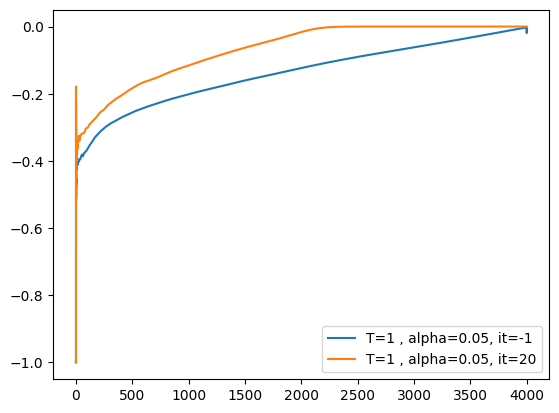

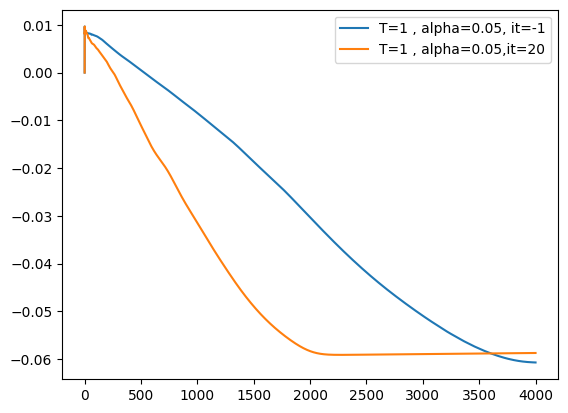

-0.06068422249396242


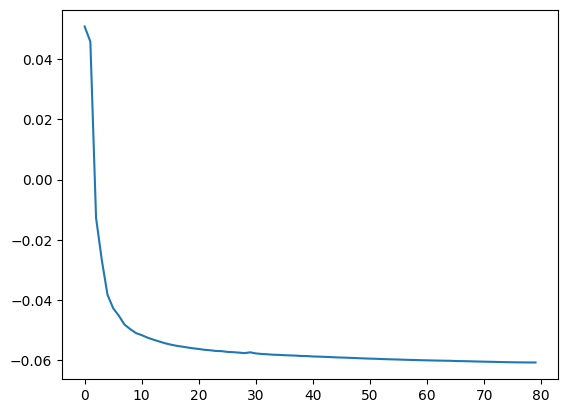

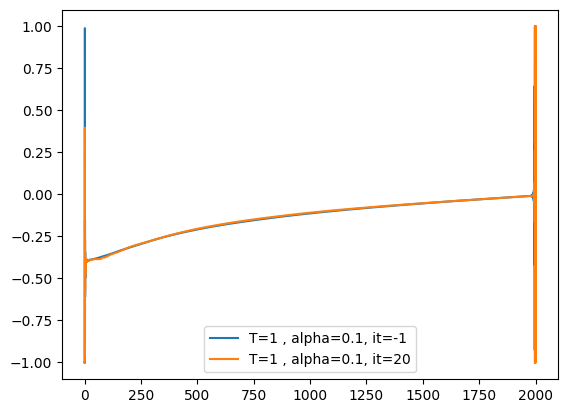

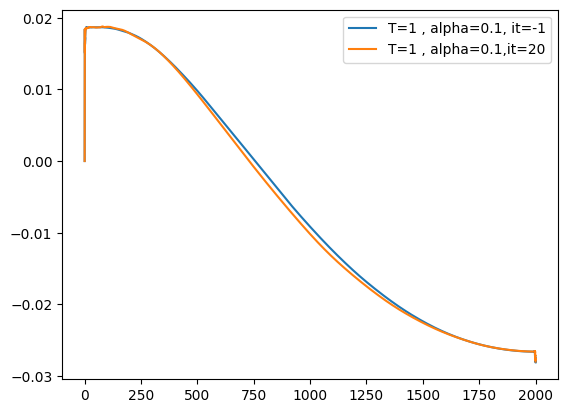

-0.02811179224069555


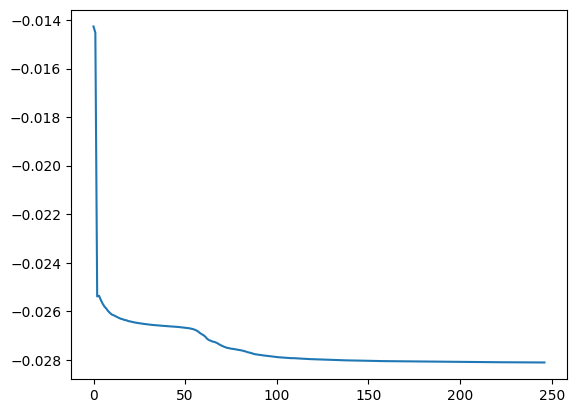

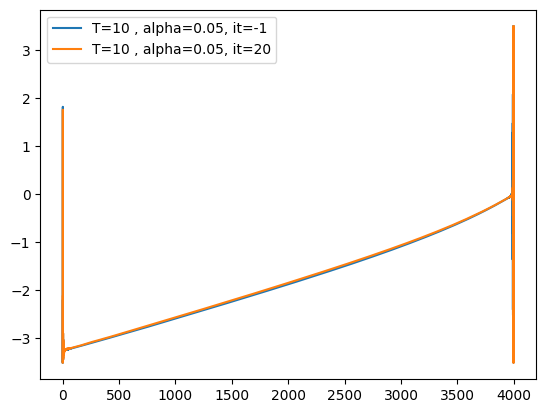

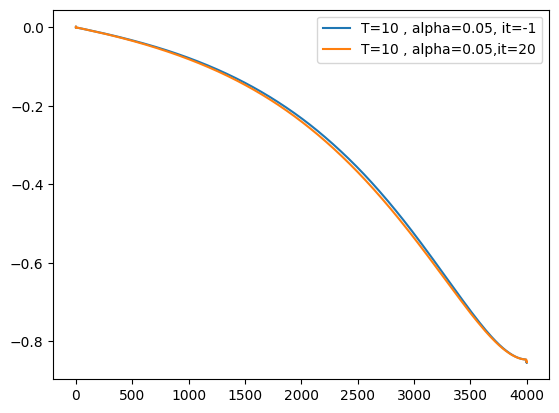

-0.8541109919412735


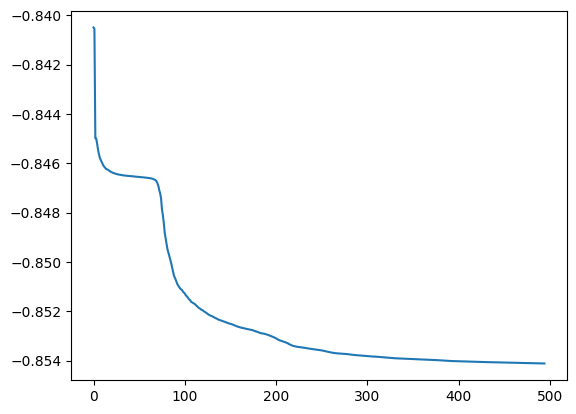

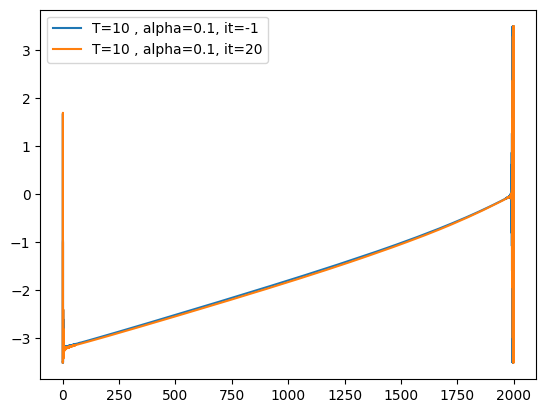

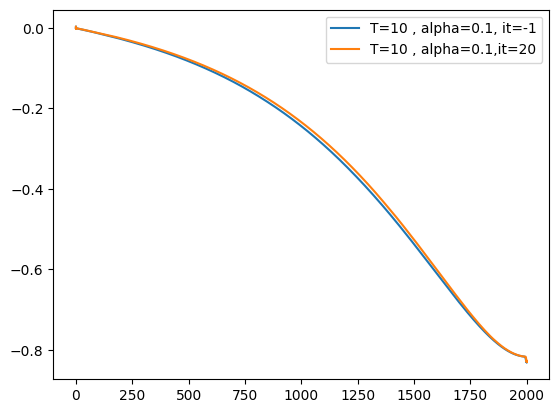

-0.8310537116799244


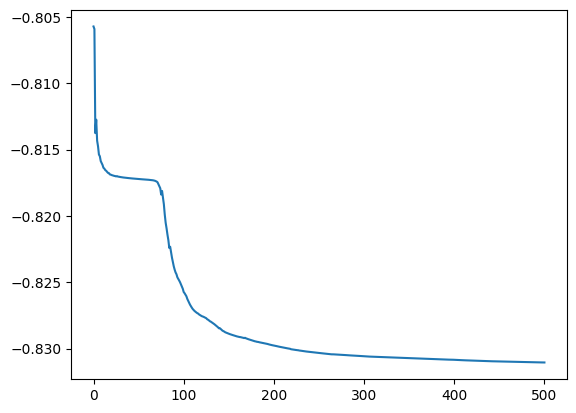

In [3]:

data_dict = {
    1: {       # T = 1 K
        0.05: opt_dict_1K_05,
        0.1:  opt_dict_1K_1
    },
    10: {      # T = 10 K
        0.05: opt_dict_10K_05,
        0.1:  opt_dict_10K_1
    }
}

plot_dict = {
    1: {       # T = 1 K
        0.05: [],
        0.1:  []
    },
    10: {      # T = 10 K
        0.05: [],
        0.1:  []
    }
}


for T in data_dict:
    for alpha in data_dict[T]:
        hx = data_dict[T][alpha]['log'][-1]['x'][:,0::3][0::2]
        dt=data_dict[T][alpha]['parameters']['dt']
        plt.plot(np.linspace(0,len(hx)*dt,len(hx)),hx,label="T={0} , alpha={1}, it=-1".format(T,alpha))

        num_its=np.shape(data_dict[T][alpha]['log'])[0]
        fin_heats=[entry['full heats'][-1] for entry in data_dict[T][alpha]['log']]

        hx = data_dict[T][alpha]['log'][num_its//2]['x'][:,0::3][0::2]
        dt=data_dict[T][alpha]['parameters']['dt']
        plt.plot(np.linspace(0,len(hx)*dt,len(hx)),hx,label="T={0} , alpha={1}, it=20".format(T,alpha))
        plt.legend()
        plt.show()
        heats=data_dict[T][alpha]['log'][-1]['full heats']
        plt.plot(np.linspace(0,len(heats)*dt,len(heats)),heats,label="T={0} , alpha={1}, it=-1".format(T,alpha))

        heats=data_dict[T][alpha]['log'][num_its//2]['full heats']
        plt.plot(np.linspace(0,len(heats)*dt,len(heats)),heats,label="T={0} , alpha={1},it=20".format(T,alpha))
        plt.legend()
        plt.show()


        
        plt.plot(fin_heats)
        print(fin_heats[-1].real)
        plt.show()
        
        plot_dict[T][alpha]=[hx,heats]

(20000,)


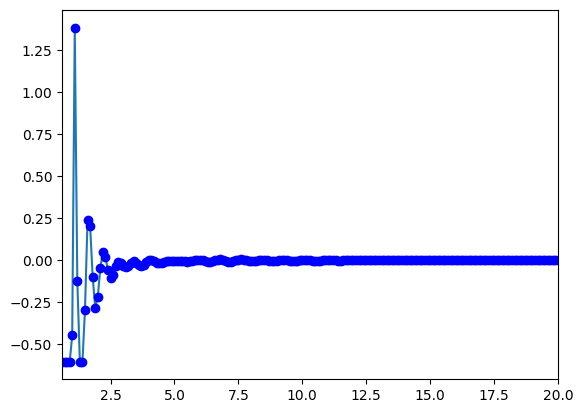

In [4]:
hx = data_dict[1][0.1]['log'][-1]['x'][:,0::3][0::2]
dt=data_dict[1][0.1]['parameters']['dt']
plt.plot(np.linspace(0,len(hx)*dt,len(hx)),hx-hx[int(20/dt)],label="T={0} , alpha={1}, it=-1".format(1,0.1))
plt.plot(np.linspace(0,len(hx)*dt,len(hx)),hx-hx[int(20/dt)],'bo',label="T={0} , alpha={1}, it=-1".format(1,0.1))
plt.xlim(0.6,20)
print(hx.flatten().shape)

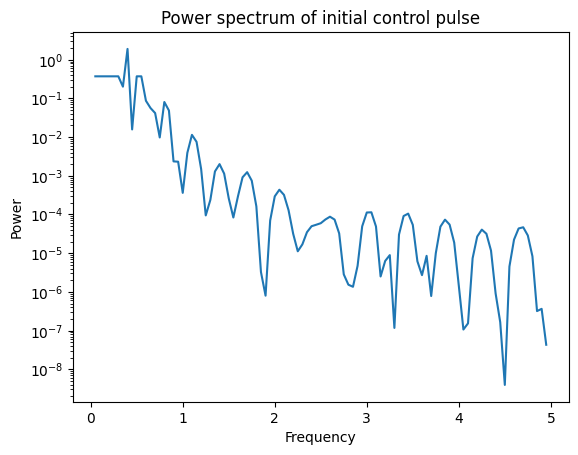

In [5]:


control = hx


n_cut = int(20/dt) 
control_kick = control[3:n_cut+3]

control_kick = control_kick - control_kick[-1]

# FFT
fft_vals = np.fft.fft(control_kick)
freqs = np.fft.fftfreq(len(control_kick), d=dt)

# Power spectrum
power = np.abs(fft_vals)**2

# Only positive frequencies
mask = freqs > 0

plt.figure()
plt.plot(freqs[mask], power[mask])
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.yscale("log")
plt.title("Power spectrum of initial control pulse")
plt.show()

In [6]:
lind_opts={(0.1,1):{},(0.05,1):{},(0.1,10):{},(0.05,10):{}}
alphas=[0.1,0.05]
temps=[1,10]

for temp in temps:
    for alpha in alphas:
        t_prot=int(200/alpha)
        with open(f'results/lindblad_control/a={alpha},T={temp}/dt=5.0/{t_prot:.0f}ps', 'rb') as f:
            lind_opts[(alpha,temp)] = dill.load(f)

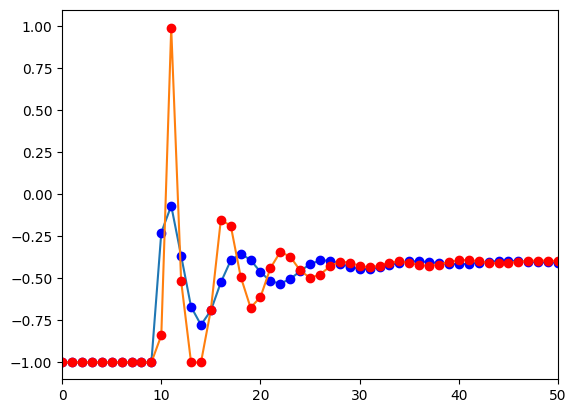

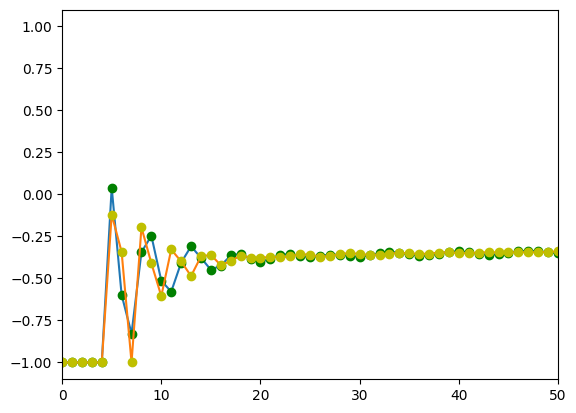

In [7]:

hx_tempo=data_dict[1][0.1]['log'][50]['x'][:,0::3][0::2].flatten()
num_steps=len(hx_tempo)
plt.plot(hx_tempo)
plt.plot(hx_tempo,'bo')
hx_tempo=data_dict[1][0.1]['log'][-1]['x'][:,0::3][0::2].flatten()
plt.plot(hx_tempo)
plt.plot(hx_tempo,'ro')
plt.xlim(0,50)
plt.show()
hx_tempo=data_dict_500[1][0.1]['log'][50]['x'][:,0::3][0::2].flatten()
num_steps=len(hx_tempo)
plt.plot(hx_tempo)
plt.plot(hx_tempo,'go')
hx_tempo=data_dict_500[1][0.1]['log'][-1]['x'][:,0::3][0::2].flatten()
plt.plot(hx_tempo)
plt.plot(hx_tempo,'yo')
plt.xlim(0,50)
plt.show()





2000.0
4000.0


/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


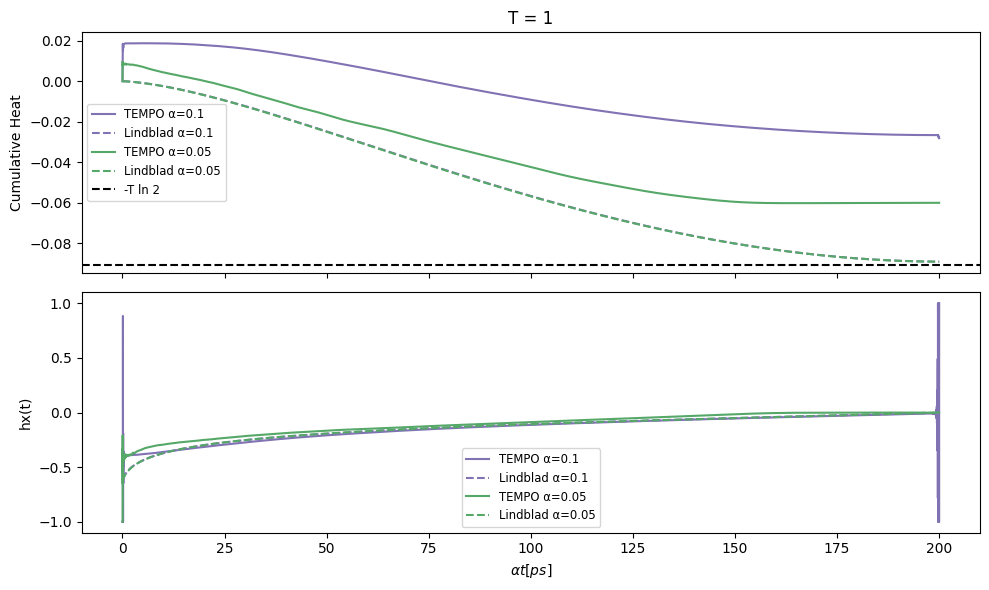

2000.0
4000.0


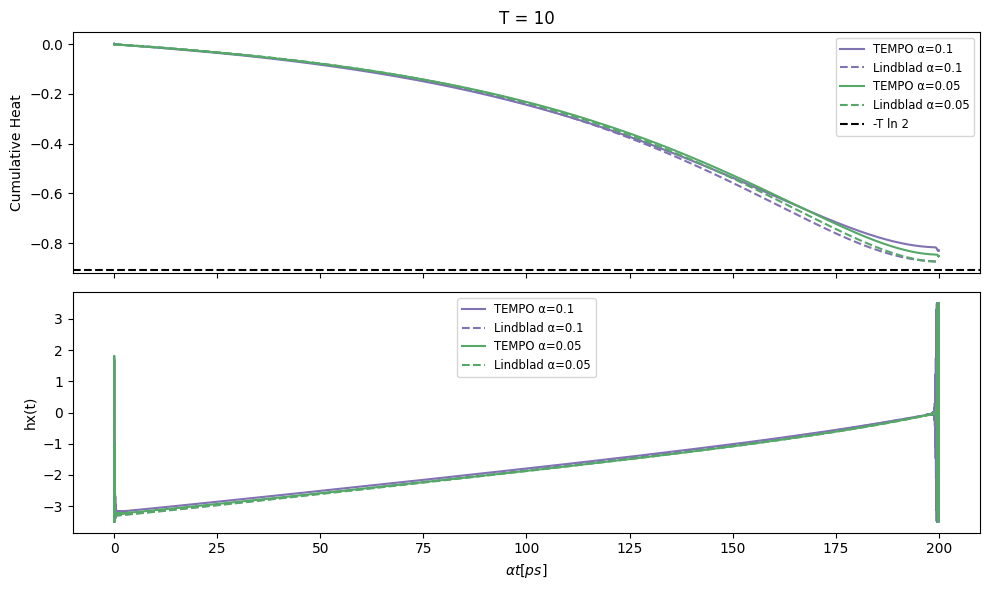

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

dt_list = [0.2, 0.25, 0.25, 0.25]
f_time_list = [2000, 2000, 4000, 4000]
temp_list = [0.131, 0.131*10, 0.131, 0.131*10]
alph_list = [0.1, 0.1, 0.05, 0.05]
omegas_start = [0.5, 3, 0.5, 3]
results_lindblad = lind_opts
nice_colors = [
    "#55A868",  # green
    "#8172B3",  # purple
    "#937860",  # brown
]
unique_alphas = sorted(set(alph_list))
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
alpha_colors = {a: nice_colors[i % len(nice_colors)] for i, a in enumerate(unique_alphas)}

# ---- group parameter sets by temperature ----
grouped = defaultdict(list)
for params in zip(dt_list, f_time_list, temp_list, alph_list, omegas_start):
    grouped[params[2]].append(params)


# ---- one figure per temperature ----
for temp, runs in grouped.items():

    T_key = int(temp / 0.131)

    fig, (ax_heat, ax_ctrl) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    for dt, f_time, temp, alph, omega_start in runs:

        color = alpha_colors[alph]
        current_it=-20
        # --- TEMPO data ---
        hx_tempo = data_dict[T_key][alph]['log'][current_it]['x'][:, 0::3][0::2]
        dt_tempo = data_dict[T_key][alph]['parameters']['dt']
        t_tempo = np.linspace(0, len(hx_tempo)*dt_tempo, len(hx_tempo))
        print(t_tempo[-1])

        heats_tempo = np.array(data_dict[T_key][alph]['log'][current_it]['full heats'])
        heats_tempo = heats_tempo[:len(t_tempo)]

        # --- Lindblad data ---
        res = results_lindblad[(alph, temp // 0.131)]["result"]
        hx_opt = res.x
        lind_heat_opt = results_lindblad[(alph, temp // 0.131)]["heats"]

        # --- Heat ---
        ax_heat.plot(alph*t_tempo, heats_tempo,
                     color=color, linestyle='-',
                     label=f"TEMPO α={alph}")

        ax_heat.plot(np.linspace(0, alph*f_time, len(lind_heat_opt)),
                     lind_heat_opt,
                     color=color, linestyle='--',
                     label=f"Lindblad α={alph}")

        # --- Control ---
        ax_ctrl.plot(alph*t_tempo, hx_tempo,
                     color=color, linestyle='-',
                     label=f"TEMPO α={alph}")

        ax_ctrl.plot(np.linspace(0, alph*f_time, len(hx_opt)),
                     hx_opt,
                     color=color, linestyle='--',
                     label=f"Lindblad α={alph}")

    # Landauer bound
    ax_heat.axhline(-temp*np.log(2), linestyle='dashed', color='black', label='-T ln 2')

    ax_heat.set_ylabel('Cumulative Heat')
    ax_heat.set_title(f"T = {T_key}")
    ax_heat.legend(fontsize='small')

    ax_ctrl.set_xlabel(r'$ \alpha t [ps]$')
    ax_ctrl.set_ylabel('hx(t)')
    ax_ctrl.legend(fontsize='small')

    plt.tight_layout()
    plt.show()

In [9]:
final_heats_a5_T10={"log":{-1:{"full heats":None}}}
final_heats_a1_T10={"log":{-1:{"full heats":None}}}

with open(f'/Users/eoinoneill/Desktop/OQuPy/results/convergence_checks/a=0.05_T=10/dt=0.1_ps=-8.0_tcut=500_x=3.5/{4000:.0f}ps', 'rb') as f:
    opt_prot_a5_T10 = dill.load(f)
    final_heats_a5_T10['log'][-1]['full heats']=opt_prot_a5_T10["heats"]


with open(f'/Users/eoinoneill/Desktop/OQuPy/results/convergence_checks/a=0.1_T=10/dt=0.1_ps=-8.0_tcut=500_x=3.5/{2000:.0f}ps', 'rb') as f:
    opt_prot_a1_T10 = dill.load(f)
    final_heats_a1_T10['log'][-1]['full heats']=opt_prot_a1_T10["heats"]

data_dict_conv = {
    1: {       # T = 1 K
        0.05: opt_dict_1K_05,
        0.1:  opt_dict_1K_1
    },
    10: {      # T = 10 K
        0.05: final_heats_a5_T10,
        0.1:  final_heats_a1_T10
    }}

0.1 0.131
-0.02811264817086334
0.05 0.131
-0.06068357627652998


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


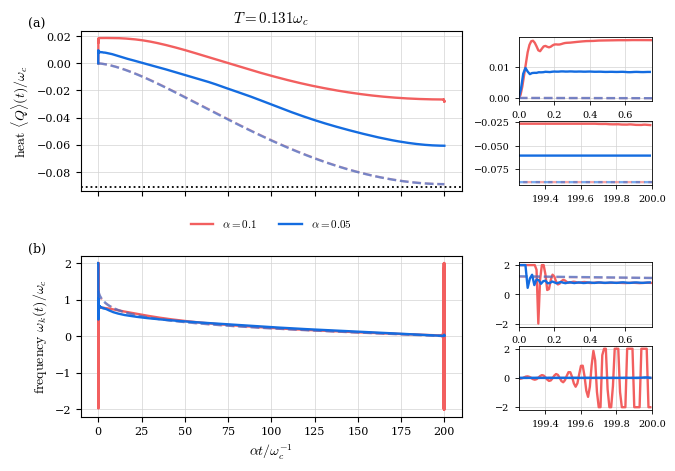

0.1 1.31
-0.8312446496925404
0.05 1.31
-0.8537397954529072


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


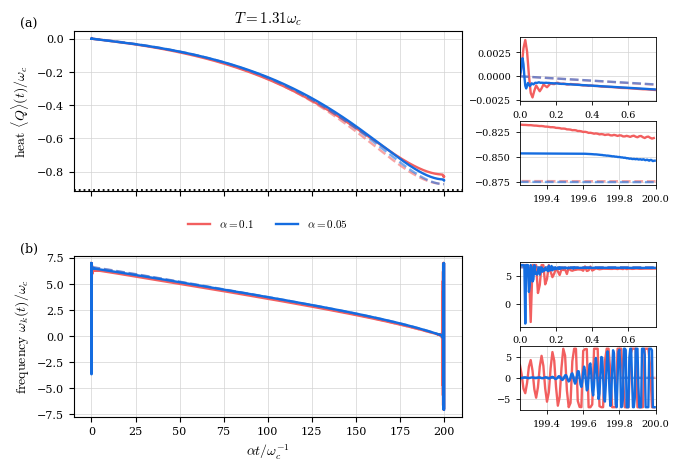

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.7,
    "mathtext.fontset": "cm",
    "font.family": "serif",
})

def style_inset(ax):
    for s in ax.spines.values():
        s.set_linewidth(0.6)
    ax.tick_params(labelsize=7, width=0.6, length=3)
    ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)

nice_colors = ["#146ce0", "#f25f5f"]  
unique_alphas = sorted(set(alph_list))
alpha_colors = {a: nice_colors[i % len(nice_colors)]
                for i, a in enumerate(unique_alphas)}

grouped = defaultdict(list)
for params in zip(dt_list, f_time_list, temp_list, alph_list, omegas_start):
    grouped[params[2]].append(params)

for temp, runs in grouped.items():
    T_key = int(temp / 0.131)

    fig, (ax_heat, ax_ctrl) = plt.subplots(
        2, 1,
        figsize=(4.6, 4.6),
        sharex=True,
        constrained_layout=True
    )

    # panel labels
    ax_heat.text(-0.14, 1.02, "(a)", transform=ax_heat.transAxes)
    ax_ctrl.text(-0.14, 1.02, "(b)", transform=ax_ctrl.transAxes)

    # insets
    def make_insets(parent):
        ax_early = inset_axes(parent, width="35%", height="40%",
                              bbox_to_anchor=(1.15, 0.56, 1, 1),
                              bbox_transform=parent.transAxes,
                              loc="lower left", borderpad=0)
        ax_late = inset_axes(parent, width="35%", height="40%",
                             bbox_to_anchor=(1.15, 0.04, 1, 1),
                             bbox_transform=parent.transAxes,
                             loc="lower left", borderpad=0)
        return ax_early, ax_late

    ax_h_early, ax_h_late = make_insets(ax_heat)
    ax_c_early, ax_c_late = make_insets(ax_ctrl)

    # --------------------------------------------------
    # PLOT DATA
    # --------------------------------------------------
    for dt, f_time, temp, alph, omega_start in runs:

        color = alpha_colors[alph]
        pale_color = color + "90"  # add alpha for transparency in hex

        current_it = -1
        t_inset_phys = 15
        


        hx_tempo = data_dict[T_key][alph]['log'][current_it]['x'][:,0::3][0::2]
        omega_tempo = -2 * hx_tempo
        dt_tempo = data_dict[T_key][alph]['parameters']['dt']
        t_phys_tempo = np.arange(len(hx_tempo))*dt_tempo
        tau_tempo = alph*t_phys_tempo
        heats_tempo = np.array(data_dict[T_key][alph]['log'][current_it]['full heats'])[:len(t_phys_tempo)]


        res = results_lindblad[(alph, temp // 0.131)]["result"]
        hx_opt = res.x
        omega_lind = -2*hx_opt
        lind_heat_opt = results_lindblad[(alph, temp // 0.131)]["heats"]
        dt_lind = f_time/len(hx_opt)
        t_phys_lind = np.arange(len(hx_opt)+1)*dt_lind
        tau_lind = alph*t_phys_lind

        print(alph, temp)
        print(heats_tempo[-1])

        ax_heat.plot(tau_tempo, heats_tempo, color=color, label=r"$\alpha = {0}$".format(alph))
        ax_heat.plot(tau_lind, lind_heat_opt, linestyle="--", color=pale_color)

        ax_ctrl.plot(tau_tempo, omega_tempo, color=color)
        ax_ctrl.plot(tau_lind[:-1], omega_lind, linestyle="--", color=pale_color)

        # insets
        n_temp = int(t_inset_phys/dt_tempo)
        n_lind = int(t_inset_phys/dt_lind)+1
        tau_inset = alph*t_inset_phys

        # early
        ax_h_early.plot(tau_tempo[:n_temp], heats_tempo[:n_temp], color=color)
        ax_h_early.plot(tau_lind[:n_lind], lind_heat_opt[:n_lind], "--", color=pale_color)
        ax_c_early.plot(tau_tempo[:n_temp], omega_tempo[:n_temp], color=color)
        ax_c_early.plot(tau_lind[:n_lind], omega_lind[:n_lind], "--", color=pale_color)
        ax_h_early.set_xlim(0, tau_inset)
        ax_c_early.set_xlim(0, tau_inset)

        # late
        ax_h_late.plot(tau_tempo[-n_temp:], heats_tempo[-n_temp:], color=color)
        ax_h_late.plot(tau_lind[-n_lind:], lind_heat_opt[-n_lind:], "--", color=pale_color)
        ax_c_late.plot(tau_tempo[-n_temp:], omega_tempo[-n_temp:], color=color)
        ax_c_late.plot(tau_lind[-n_lind:], omega_lind[-n_lind:], "--", color=pale_color)
        ax_h_late.set_xlim(alph*(f_time-t_inset_phys), alph*f_time)
        ax_c_late.set_xlim(alph*(f_time-t_inset_phys), alph*f_time)

        ax_heat.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.3), ncol=3,fontsize=8)

    # style insets
    for ax in [ax_h_early, ax_h_late, ax_c_early, ax_c_late]:
        style_inset(ax)

    # Landauer line
    ax_heat.axhline(-temp*np.log(2), linestyle=":", color="black", linewidth=1.3)

    ax_heat.set_ylabel(r"$\text{heat } \langle Q \rangle (t)  / \omega_c$")
    ax_heat.set_title(r"$T = {0} \omega_c$".format(temp))
    ax_ctrl.set_ylabel(r"$\text{frequency } \omega_k(t) / \omega_c$")
    ax_ctrl.set_xlabel(r"$\alpha t / \omega_c^{-1}$")

    # Main grid
    for ax in [ax_heat, ax_ctrl]:
        ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
        ax.set_axisbelow(True)

    plt.savefig('Q_v_prottime_{0}.eps'.format(temp), format='eps', bbox_inches='tight')
    plt.show()

(0.0, 0.2)

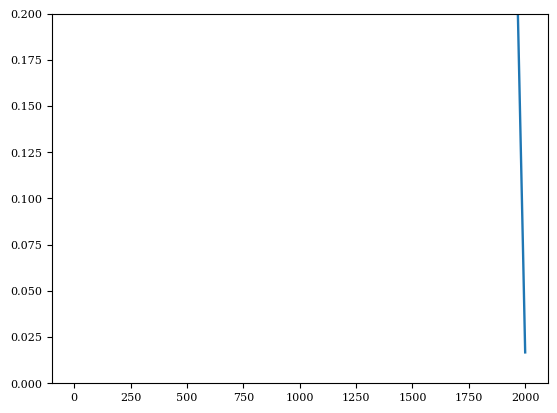

In [11]:
alp=0.1
temp=0.131*10
res = results_lindblad[(alph, temp // 0.131)]["result"]
hx_opt = res.x
omega_lind = -2*hx_opt

plt.plot(np.linspace(0,2000,len(omega_lind)),omega_lind)
plt.ylim(0,0.2)

# Comparing thermodynamic length controls with Lindblad + gradient descent

In [ ]:
# therm length controls from mathematica (independent of alpha and protocol time)

high_temp_control=[6.62, 6.61358, 6.60715, 6.60073, 6.5943, 6.58787, 6.58144, 6.575, \
6.56857, 6.56213, 6.55569, 6.54924, 6.5428, 6.53635, 6.5299, 6.52345, \
6.51699, 6.51054, 6.50408, 6.49762, 6.49115, 6.48469, 6.47822, \
6.47175, 6.46528, 6.45881, 6.45233, 6.44585, 6.43937, 6.43289, \
6.42641, 6.41992, 6.41343, 6.40694, 6.40045, 6.39395, 6.38745, \
6.38095, 6.37445, 6.36795, 6.36144, 6.35493, 6.34842, 6.34191, \
6.33539, 6.32888, 6.32236, 6.31583, 6.30931, 6.30278, 6.29626, \
6.28973, 6.28319, 6.27666, 6.27012, 6.26358, 6.25704, 6.2505, \
6.24395, 6.2374, 6.23085, 6.2243, 6.21775, 6.21119, 6.20463, 6.19807, \
6.1915, 6.18494, 6.17837, 6.1718, 6.16523, 6.15866, 6.15208, 6.1455, \
6.13892, 6.13234, 6.12575, 6.11916, 6.11257, 6.10598, 6.09939, \
6.09279, 6.08619, 6.07959, 6.07299, 6.06638, 6.05977, 6.05316, \
6.04655, 6.03994, 6.03332, 6.0267, 6.02008, 6.01346, 6.00683, \
6.00021, 5.99358, 5.98695, 5.98031, 5.97368, 5.96704, 5.9604, \
5.95375, 5.94711, 5.94046, 5.93381, 5.92716, 5.9205, 5.91385, \
5.90719, 5.90053, 5.89386, 5.8872, 5.88053, 5.87386, 5.86719, \
5.86052, 5.85384, 5.84716, 5.84048, 5.8338, 5.82711, 5.82042, \
5.81373, 5.80704, 5.80035, 5.79365, 5.78695, 5.78025, 5.77355, \
5.76684, 5.76013, 5.75342, 5.74671, 5.73999, 5.73328, 5.72656, \
5.71984, 5.71311, 5.70639, 5.69966, 5.69293, 5.68619, 5.67946, \
5.67272, 5.66598, 5.65924, 5.65249, 5.64575, 5.639, 5.63225, 5.62549, \
5.61874, 5.61198, 5.60522, 5.59846, 5.59169, 5.58492, 5.57815, \
5.57138, 5.56461, 5.55783, 5.55105, 5.54427, 5.53749, 5.5307, \
5.52392, 5.51713, 5.51033, 5.50354, 5.49674, 5.48994, 5.48314, \
5.47633, 5.46953, 5.46272, 5.45591, 5.44909, 5.44228, 5.43546, \
5.42864, 5.42182, 5.41499, 5.40816, 5.40133, 5.3945, 5.38767, \
5.38083, 5.37399, 5.36715, 5.36031, 5.35346, 5.34661, 5.33976, \
5.33291, 5.32605, 5.31919, 5.31233, 5.30547, 5.2986, 5.29174, \
5.28487, 5.27799, 5.27112, 5.26424, 5.25736, 5.25048, 5.24359, \
5.23671, 5.22982, 5.22293, 5.21603, 5.20914, 5.20224, 5.19534, \
5.18843, 5.18153, 5.17462, 5.16771, 5.16079, 5.15388, 5.14696, \
5.14004, 5.13312, 5.12619, 5.11926, 5.11233, 5.1054, 5.09846, \
5.09153, 5.08459, 5.07764, 5.0707, 5.06375, 5.0568, 5.04985, 5.04289, \
5.03593, 5.02897, 5.02201, 5.01505, 5.00808, 5.00111, 4.99414, \
4.98716, 4.98018, 4.9732, 4.96622, 4.95923, 4.95225, 4.94526, \
4.93826, 4.93127, 4.92427, 4.91727, 4.91027, 4.90326, 4.89625, \
4.88924, 4.88223, 4.87521, 4.8682, 4.86118, 4.85415, 4.84713, 4.8401, \
4.83307, 4.82603, 4.819, 4.81196, 4.80491, 4.79787, 4.79082, 4.78377, \
4.77672, 4.76967, 4.76261, 4.75555, 4.74849, 4.74142, 4.73435, \
4.72728, 4.72021, 4.71313, 4.70605, 4.69897, 4.69189, 4.6848, \
4.67771, 4.67062, 4.66352, 4.65643, 4.64933, 4.64222, 4.63512, \
4.62801, 4.6209, 4.61378, 4.60667, 4.59955, 4.59242, 4.5853, 4.57817, \
4.57104, 4.56391, 4.55677, 4.54963, 4.54249, 4.53535, 4.5282, \
4.52105, 4.51389, 4.50674, 4.49958, 4.49242, 4.48525, 4.47809, \
4.47092, 4.46374, 4.45657, 4.44939, 4.4422, 4.43502, 4.42783, \
4.42064, 4.41345, 4.40625, 4.39905, 4.39185, 4.38464, 4.37744, \
4.37022, 4.36301, 4.35579, 4.34857, 4.34135, 4.33412, 4.32689, \
4.31966, 4.31243, 4.30519, 4.29795, 4.2907, 4.28345, 4.2762, 4.26895, \
4.26169, 4.25443, 4.24717, 4.2399, 4.23263, 4.22536, 4.21809, \
4.21081, 4.20352, 4.19624, 4.18895, 4.18166, 4.17436, 4.16707, \
4.15977, 4.15246, 4.14515, 4.13784, 4.13053, 4.12321, 4.11589, \
4.10857, 4.10124, 4.09391, 4.08657, 4.07924, 4.0719, 4.06455, 4.0572, \
4.04985, 4.0425, 4.03514, 4.02778, 4.02042, 4.01305, 4.00568, 3.9983, \
3.99092, 3.98354, 3.97616, 3.96877, 3.96137, 3.95398, 3.94658, \
3.93918, 3.93177, 3.92436, 3.91695, 3.90953, 3.90211, 3.89468, \
3.88725, 3.87982, 3.87239, 3.86495, 3.8575, 3.85006, 3.84261, \
3.83515, 3.8277, 3.82023, 3.81277, 3.8053, 3.79783, 3.79035, 3.78287, \
3.77538, 3.76789, 3.7604, 3.7529, 3.7454, 3.7379, 3.73039, 3.72288, \
3.71536, 3.70784, 3.70032, 3.69279, 3.68526, 3.67772, 3.67018, \
3.66264, 3.65509, 3.64753, 3.63998, 3.63242, 3.62485, 3.61728, \
3.60971, 3.60213, 3.59455, 3.58696, 3.57937, 3.57177, 3.56417, \
3.55657, 3.54896, 3.54135, 3.53373, 3.52611, 3.51848, 3.51085, \
3.50322, 3.49558, 3.48793, 3.48028, 3.47263, 3.46497, 3.45731, \
3.44964, 3.44197, 3.43429, 3.42661, 3.41892, 3.41123, 3.40353, \
3.39583, 3.38813, 3.38042, 3.3727, 3.36498, 3.35726, 3.34953, \
3.34179, 3.33405, 3.32631, 3.31856, 3.3108, 3.30304, 3.29527, 3.2875, \
3.27973, 3.27194, 3.26416, 3.25637, 3.24857, 3.24077, 3.23296, \
3.22514, 3.21733, 3.2095, 3.20167, 3.19384, 3.186, 3.17815, 3.1703, \
3.16244, 3.15458, 3.14671, 3.13883, 3.13095, 3.12307, 3.11517, \
3.10728, 3.09937, 3.09146, 3.08355, 3.07563, 3.0677, 3.05976, \
3.05182, 3.04388, 3.03593, 3.02797, 3.02, 3.01203, 3.00405, 2.99607, \
2.98808, 2.98008, 2.97208, 2.96407, 2.95606, 2.94803, 2.94, 2.93197, \
2.92393, 2.91588, 2.90782, 2.89976, 2.89169, 2.88361, 2.87553, \
2.86744, 2.85934, 2.85124, 2.84312, 2.835, 2.82688, 2.81875, 2.8106, \
2.80246, 2.7943, 2.78614, 2.77797, 2.76979, 2.7616, 2.75341, 2.74521, \
2.737, 2.72878, 2.72056, 2.71233, 2.70409, 2.69584, 2.68758, 2.67932, \
2.67104, 2.66276, 2.65447, 2.64618, 2.63787, 2.62956, 2.62123, \
2.6129, 2.60456, 2.59621, 2.58786, 2.57949, 2.57111, 2.56273, \
2.55434, 2.54593, 2.53752, 2.5291, 2.52067, 2.51223, 2.50379, \
2.49533, 2.48686, 2.47838, 2.4699, 2.4614, 2.45289, 2.44438, 2.43585, \
2.42731, 2.41877, 2.41021, 2.40165, 2.39307, 2.38448, 2.37588, \
2.36727, 2.35866, 2.35003, 2.34138, 2.33273, 2.32407, 2.3154, \
2.30671, 2.29802, 2.28931, 2.28059, 2.27186, 2.26312, 2.25436, \
2.2456, 2.23682, 2.22803, 2.21923, 2.21042, 2.20159, 2.19275, 2.1839, \
2.17504, 2.16617, 2.15728, 2.14838, 2.13946, 2.13053, 2.12159, \
2.11264, 2.10367, 2.09469, 2.0857, 2.07669, 2.06767, 2.05863, \
2.04958, 2.04052, 2.03144, 2.02235, 2.01324, 2.00412, 1.99498, \
1.98583, 1.97666, 1.96748, 1.95828, 1.94906, 1.93984, 1.93059, \
1.92133, 1.91205, 1.90276, 1.89345, 1.88412, 1.87478, 1.86542, \
1.85605, 1.84665, 1.83724, 1.82781, 1.81837, 1.8089, 1.79942, \
1.78992, 1.7804, 1.77087, 1.76131, 1.75174, 1.74214, 1.73253, 1.7229, \
1.71325, 1.70358, 1.69389, 1.68417, 1.67444, 1.66469, 1.65492, \
1.64512, 1.63531, 1.62547, 1.61561, 1.60573, 1.59583, 1.58591, \
1.57596, 1.56599, 1.556, 1.54598, 1.53595, 1.52588, 1.5158, 1.50569, \
1.49555, 1.48539, 1.47521, 1.465, 1.45476, 1.4445, 1.43421, 1.4239, \
1.41355, 1.40319, 1.39279, 1.38237, 1.37192, 1.36144, 1.35093, \
1.3404, 1.32983, 1.31924, 1.30861, 1.29796, 1.28727, 1.27655, \
1.26581, 1.25503, 1.24422, 1.23337, 1.22249, 1.21158, 1.20064, \
1.18966, 1.17865, 1.1676, 1.15652, 1.1454, 1.13425, 1.12306, 1.11183, \
1.10057, 1.08926, 1.07792, 1.06654, 1.05512, 1.04366, 1.03215, \
1.02061, 1.00903, 0.997399, 0.985729, 0.974015, 0.962258, 0.950456, \
0.938608, 0.926715, 0.914775, 0.902788, 0.890753, 0.87867, 0.866537, \
0.854354, 0.842121, 0.829836, 0.817498, 0.805108, 0.792664, 0.780166, \
0.767612, 0.755002, 0.742334, 0.729609, 0.716825, 0.70398, 0.691076, \
0.678109, 0.665079, 0.651986, 0.638828, 0.625604, 0.612313, 0.598954, \
0.585526, 0.572028, 0.558458, 0.544815, 0.531098, 0.517305, 0.503436, \
0.489489, 0.475462, 0.461355, 0.447165, 0.432891, 0.418532, 0.404086, \
0.389551, 0.374926, 0.360209, 0.345398, 0.330491, 0.315487, 0.300384, \
0.285178, 0.26987, 0.254455, 0.238933, 0.2233, 0.207556, 0.191696, \
0.175719, 0.159622, 0.143403, 0.127059, 0.110586, 0.0939832, \
0.0772461, 0.060372, 0.0433578, 0.0262]
low_temp_control=[1.24, 1.20888, 1.181, 1.15576, 1.1327, 1.11147, 1.09182, 1.07352, \
1.05641, 1.04034, 1.02519, 1.01087, 0.997285, 0.98437, 0.972062, \
0.960307, 0.949058, 0.938275, 0.927919, 0.917961, 0.908369, 0.89912, \
0.890189, 0.881556, 0.873202, 0.865109, 0.857263, 0.849648, 0.842252, \
0.835062, 0.828068, 0.82126, 0.814627, 0.808162, 0.801855, 0.795701, \
0.789691, 0.783819, 0.778079, 0.772466, 0.766973, 0.761597, 0.756331, \
0.751173, 0.746116, 0.741159, 0.736296, 0.731525, 0.726842, 0.722244, \
0.717728, 0.713291, 0.708931, 0.704644, 0.700429, 0.696283, 0.692205, \
0.68819, 0.684239, 0.680349, 0.676518, 0.672744, 0.669026, 0.665362, \
0.661751, 0.658191, 0.65468, 0.651218, 0.647803, 0.644434, 0.641109, \
0.637828, 0.634589, 0.631391, 0.628234, 0.625115, 0.622035, 0.618993, \
0.615987, 0.613017, 0.610081, 0.60718, 0.604311, 0.601475, 0.598671, \
0.595898, 0.593156, 0.590443, 0.587759, 0.585104, 0.582476, 0.579876, \
0.577303, 0.574755, 0.572234, 0.569738, 0.567266, 0.564818, 0.562395, \
0.559994, 0.557616, 0.555261, 0.552928, 0.550616, 0.548326, 0.546056, \
0.543806, 0.541577, 0.539368, 0.537177, 0.535006, 0.532853, 0.530719, \
0.528603, 0.526505, 0.524423, 0.52236, 0.520313, 0.518282, 0.516268, \
0.51427, 0.512288, 0.510321, 0.50837, 0.506434, 0.504512, 0.502606, \
0.500713, 0.498835, 0.49697, 0.49512, 0.493283, 0.491459, 0.489649, \
0.487851, 0.486066, 0.484294, 0.482534, 0.480786, 0.479051, 0.477327, \
0.475615, 0.473914, 0.472225, 0.470548, 0.468881, 0.467225, 0.46558, \
0.463946, 0.462322, 0.460708, 0.459105, 0.457512, 0.455929, 0.454355, \
0.452792, 0.451238, 0.449693, 0.448158, 0.446632, 0.445115, 0.443607, \
0.442108, 0.440618, 0.439136, 0.437663, 0.436199, 0.434743, 0.433295, \
0.431855, 0.430424, 0.429, 0.427585, 0.426177, 0.424776, 0.423384, \
0.421999, 0.420621, 0.419251, 0.417888, 0.416532, 0.415184, 0.413842, \
0.412507, 0.41118, 0.409859, 0.408545, 0.407237, 0.405936, 0.404642, \
0.403354, 0.402072, 0.400797, 0.399528, 0.398265, 0.397009, 0.395758, \
0.394513, 0.393275, 0.392042, 0.390815, 0.389594, 0.388378, 0.387168, \
0.385964, 0.384765, 0.383572, 0.382384, 0.381201, 0.380024, 0.378852, \
0.377685, 0.376524, 0.375367, 0.374216, 0.373069, 0.371928, 0.370792, \
0.36966, 0.368533, 0.367411, 0.366294, 0.365181, 0.364073, 0.36297, \
0.361871, 0.360777, 0.359687, 0.358602, 0.357521, 0.356444, 0.355372, \
0.354304, 0.35324, 0.352181, 0.351125, 0.350074, 0.349027, 0.347984, \
0.346945, 0.34591, 0.344879, 0.343851, 0.342828, 0.341809, 0.340793, \
0.339781, 0.338773, 0.337769, 0.336768, 0.335771, 0.334778, 0.333788, \
0.332802, 0.331819, 0.33084, 0.329865, 0.328892, 0.327924, 0.326958, \
0.325996, 0.325038, 0.324082, 0.32313, 0.322182, 0.321236, 0.320294, \
0.319355, 0.318419, 0.317486, 0.316556, 0.31563, 0.314706, 0.313786, \
0.312868, 0.311954, 0.311042, 0.310133, 0.309228, 0.308325, 0.307425, \
0.306528, 0.305634, 0.304742, 0.303854, 0.302968, 0.302085, 0.301205, \
0.300327, 0.299452, 0.29858, 0.29771, 0.296843, 0.295979, 0.295117, \
0.294258, 0.293401, 0.292547, 0.291695, 0.290846, 0.29, 0.289156, \
0.288314, 0.287474, 0.286638, 0.285803, 0.284971, 0.284141, 0.283314, \
0.282489, 0.281666, 0.280845, 0.280027, 0.279211, 0.278397, 0.277586, \
0.276777, 0.27597, 0.275165, 0.274362, 0.273561, 0.272763, 0.271967, \
0.271172, 0.27038, 0.26959, 0.268802, 0.268016, 0.267232, 0.26645, \
0.265671, 0.264893, 0.264117, 0.263343, 0.262571, 0.261801, 0.261033, \
0.260267, 0.259502, 0.25874, 0.257979, 0.257221, 0.256464, 0.255709, \
0.254956, 0.254205, 0.253455, 0.252707, 0.251961, 0.251217, 0.250475, \
0.249734, 0.248995, 0.248258, 0.247523, 0.246789, 0.246057, 0.245326, \
0.244598, 0.243871, 0.243145, 0.242421, 0.241699, 0.240979, 0.24026, \
0.239542, 0.238827, 0.238112, 0.2374, 0.236689, 0.235979, 0.235271, \
0.234565, 0.23386, 0.233156, 0.232455, 0.231754, 0.231055, 0.230358, \
0.229662, 0.228967, 0.228274, 0.227582, 0.226892, 0.226203, 0.225516, \
0.22483, 0.224145, 0.223462, 0.22278, 0.222099, 0.22142, 0.220742, \
0.220066, 0.21939, 0.218717, 0.218044, 0.217373, 0.216703, 0.216034, \
0.215367, 0.214701, 0.214036, 0.213373, 0.21271, 0.212049, 0.211389, \
0.210731, 0.210074, 0.209417, 0.208762, 0.208109, 0.207456, 0.206805, \
0.206155, 0.205506, 0.204858, 0.204211, 0.203566, 0.202921, 0.202278, \
0.201636, 0.200995, 0.200355, 0.199716, 0.199079, 0.198442, 0.197807, \
0.197172, 0.196539, 0.195907, 0.195276, 0.194646, 0.194016, 0.193388, \
0.192761, 0.192136, 0.191511, 0.190887, 0.190264, 0.189642, 0.189021, \
0.188401, 0.187782, 0.187165, 0.186548, 0.185932, 0.185317, 0.184703, \
0.18409, 0.183478, 0.182867, 0.182256, 0.181647, 0.181039, 0.180431, \
0.179825, 0.179219, 0.178615, 0.178011, 0.177408, 0.176806, 0.176205, \
0.175605, 0.175006, 0.174407, 0.173809, 0.173213, 0.172617, 0.172022, \
0.171428, 0.170834, 0.170242, 0.16965, 0.169059, 0.168469, 0.16788, \
0.167292, 0.166704, 0.166117, 0.165531, 0.164946, 0.164362, 0.163778, \
0.163195, 0.162613, 0.162032, 0.161451, 0.160872, 0.160293, 0.159714, \
0.159137, 0.15856, 0.157984, 0.157409, 0.156834, 0.15626, 0.155687, \
0.155115, 0.154543, 0.153972, 0.153402, 0.152832, 0.152263, 0.151695, \
0.151127, 0.15056, 0.149994, 0.149429, 0.148864, 0.1483, 0.147736, \
0.147173, 0.146611, 0.14605, 0.145489, 0.144929, 0.144369, 0.14381, \
0.143252, 0.142694, 0.142137, 0.14158, 0.141024, 0.140469, 0.139914, \
0.13936, 0.138807, 0.138254, 0.137702, 0.13715, 0.136599, 0.136049, \
0.135499, 0.134949, 0.1344, 0.133852, 0.133305, 0.132758, 0.132211, \
0.131665, 0.13112, 0.130575, 0.13003, 0.129486, 0.128943, 0.1284, \
0.127858, 0.127317, 0.126775, 0.126235, 0.125695, 0.125155, 0.124616, \
0.124077, 0.123539, 0.123001, 0.122464, 0.121928, 0.121391, 0.120856, \
0.120321, 0.119786, 0.119252, 0.118718, 0.118185, 0.117652, 0.117119, \
0.116588, 0.116056, 0.115525, 0.114995, 0.114464, 0.113935, 0.113406, \
0.112877, 0.112348, 0.111821, 0.111293, 0.110766, 0.110239, 0.109713, \
0.109187, 0.108662, 0.108137, 0.107612, 0.107088, 0.106564, 0.106041, \
0.105518, 0.104995, 0.104473, 0.103951, 0.10343, 0.102909, 0.102388, \
0.101868, 0.101348, 0.100829, 0.100309, 0.0997906, 0.0992721, \
0.098754, 0.0982363, 0.0977189, 0.0972018, 0.0966851, 0.0961688, \
0.0956527, 0.0951371, 0.0946217, 0.0941067, 0.093592, 0.0930777, \
0.0925637, 0.09205, 0.0915366, 0.0910235, 0.0905108, 0.0899983, \
0.0894862, 0.0889744, 0.0884628, 0.0879516, 0.0874407, 0.0869301, \
0.0864197, 0.0859097, 0.0853999, 0.0848904, 0.0843813, 0.0838723, \
0.0833637, 0.0828553, 0.0823473, 0.0818394, 0.0813319, 0.0808246, \
0.0803176, 0.0798108, 0.0793043, 0.078798, 0.078292, 0.0777863, \
0.0772808, 0.0767755, 0.0762705, 0.0757657, 0.0752611, 0.0747568, \
0.0742527, 0.0737489, 0.0732452, 0.0727418, 0.0722387, 0.0717357, \
0.0712329, 0.0707304, 0.0702281, 0.069726, 0.0692241, 0.0687224, \
0.0682209, 0.0677196, 0.0672184, 0.0667175, 0.0662168, 0.0657163, \
0.0652159, 0.0647158, 0.0642158, 0.063716, 0.0632164, 0.062717, \
0.0622177, 0.0617186, 0.0612197, 0.0607209, 0.0602223, 0.0597239, \
0.0592256, 0.0587275, 0.0582295, 0.0577317, 0.057234, 0.0567365, \
0.0562391, 0.0557419, 0.0552448, 0.0547478, 0.054251, 0.0537543, \
0.0532577, 0.0527613, 0.052265, 0.0517688, 0.0512727, 0.0507768, \
0.0502809, 0.0497852, 0.0492896, 0.0487941, 0.0482987, 0.0478035, \
0.0473083, 0.0468132, 0.0463182, 0.0458233, 0.0453285, 0.0448338, \
0.0443392, 0.0438447, 0.0433502, 0.0428559, 0.0423616, 0.0418674, \
0.0413732, 0.0408792, 0.0403852, 0.0398913, 0.0393974, 0.0389036, \
0.0384099, 0.0379162, 0.0374226, 0.036929, 0.0364355, 0.035942, \
0.0354486, 0.0349553, 0.0344619, 0.0339686, 0.0334754, 0.0329822, \
0.032489, 0.0319958, 0.0315027, 0.0310096, 0.0305166, 0.0300235, \
0.0295305, 0.0290375, 0.0285445, 0.0280515, 0.0275585, 0.0270655, \
0.0265726, 0.0260796, 0.0255867, 0.0250937, 0.0246007, 0.0241078, \
0.0236148, 0.0231218, 0.0226288, 0.0221358, 0.0216428, 0.0211497, \
0.0206566, 0.0201635, 0.0196704, 0.0191773, 0.0186841, 0.0181909, \
0.0176976, 0.0172043, 0.016711, 0.0162176, 0.0157242, 0.0152307, \
0.0147372, 0.0142437, 0.01375, 0.0132563, 0.0127626, 0.0122688, \
0.0117749, 0.011281, 0.010787, 0.0102929, 0.0097988, 0.00930458, \
0.00881029, 0.00831591, 0.00782145, 0.0073269, 0.00683227, \
0.00633755, 0.00584273, 0.00534782, 0.00485282, 0.00435771, \
0.0038625, 0.00336719, 0.00287177, 0.00237624, 0.0018806, 0.00138485, \
0.000888981, 0.000392993]

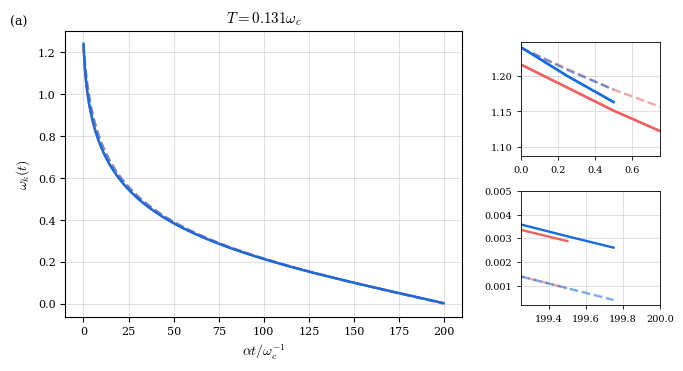

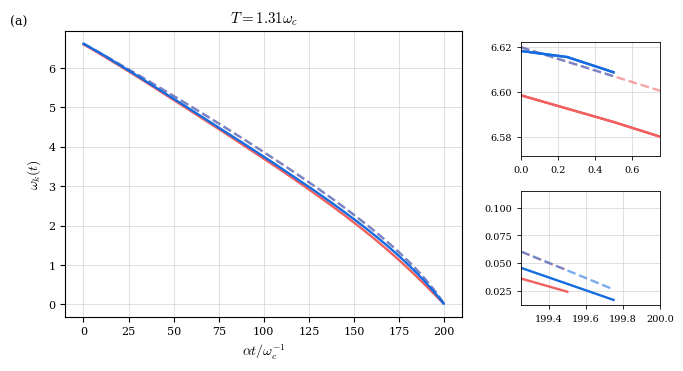

In [ ]:
results_Dsolve={
    (0.05,1): low_temp_control, (0.05,10): high_temp_control, (0.1,1): low_temp_control[::2], (0.1,10): high_temp_control[::2]}

def lagrangian_density(r, t, alpha,beta):
    r = np.asarray(r)
    t = np.asarray(t)

    r_dot = np.gradient(r, t)
 

    L = (r_dot**2) * np.tanh(r / 2) / (
        2 * alpha * r * np.exp(-r) * (np.cosh(r / 2)**2)
    ) * (beta**2)

    return L

for temp, runs in grouped.items():
    T_key = int(temp / 0.131)

    fig, ax = plt.subplots(
        figsize=(4.6, 3.6),
        constrained_layout=True
    )

    ax.text(-0.14, 1.02, "(a)", transform=ax.transAxes)

    # inset axes
    def make_insets(parent):
        ax_early = inset_axes(parent, width="35%", height="40%",
                              bbox_to_anchor=(1.15, 0.56, 1, 1),
                              bbox_transform=parent.transAxes,
                              loc="lower left", borderpad=0)
        ax_late = inset_axes(parent, width="35%", height="40%",
                             bbox_to_anchor=(1.15, 0.04, 1, 1),
                             bbox_transform=parent.transAxes,
                             loc="lower left", borderpad=0)
        return ax_early, ax_late

    ax_early, ax_late = make_insets(ax)

    for dt, f_time, temp, alph, omega_start in runs:

        color = alpha_colors[alph]
        pale_color = color + "90" 


        res = results_lindblad[(alph, temp // 0.131)]["result"]
        
        hx_opt = res.x
        omega_lind = -2 * hx_opt

        omega_Dsolve= results_Dsolve[(alph,temp//0.131)]

        dt_lind = f_time / len(hx_opt)
        t_phys_lind = np.arange(len(hx_opt)) * dt_lind
        tau_lind = alph * t_phys_lind

        ax_early.plot(tau_lind[:n_lind], omega_lind[:n_lind], color=color)

        ax.plot(tau_lind, omega_lind, color=color,
                label=r"$\alpha = {0}$".format(alph))
        
        ax.plot(tau_lind, omega_Dsolve, "--", color=pale_color,
                label=r"$\alpha = {0}$".format(alph))


        t_inset_phys = 15
        n_lind = int(t_inset_phys / dt_lind)
        tau_inset = alph * t_inset_phys

        
        ax_early.plot(tau_lind[:n_lind], omega_Dsolve[:n_lind], "--",color=pale_color)
        ax_early.plot(tau_lind[:n_lind], omega_lind[:n_lind], color=color)
        ax_early.set_xlim(0, tau_inset)

        ax_late.plot(tau_lind[-n_lind:], omega_Dsolve[-n_lind:], "--",color=pale_color)
        ax_late.plot(tau_lind[-n_lind:], omega_lind[-n_lind:], color=color)
        ax_late.set_xlim(alph*(f_time - t_inset_phys), alph*f_time)

    # style insets
    for ax_i in [ax_early, ax_late]:
        style_inset(ax_i)

    # labels
    ax.set_ylabel(r"$\omega_k (t)$")
    ax.set_xlabel(r"$\alpha t / \omega_c^{-1}$")
    ax.set_title(r"$T = {0} \omega_c$".format(temp))

    """
    ax.legend(frameon=False, loc="lower center",
              bbox_to_anchor=(0.5, -0.35), ncol=3)
    """
    # grid
    ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)

    plt.savefig(f'Lagrangian_v_time_{temp}.pdf',
                format='pdf', bbox_inches='tight')
    plt.show()


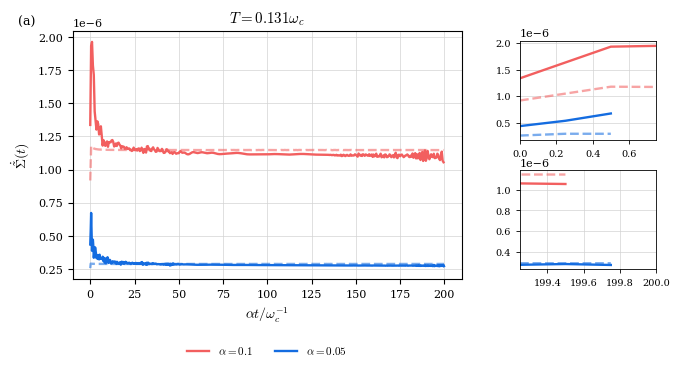

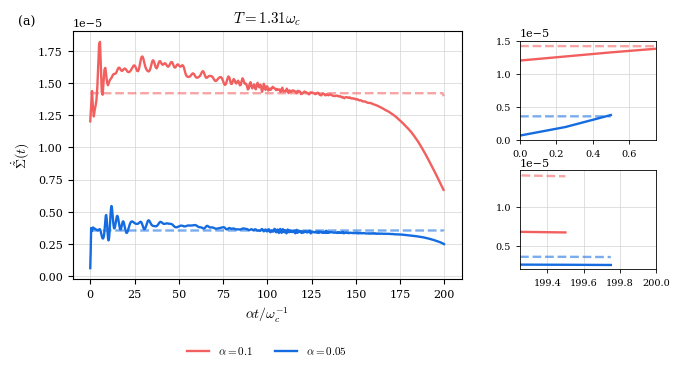

In [ ]:
def lagrangian_density(r, t, alpha,beta):
    r = beta*np.asarray(r)
    t = np.asarray(t)

    r_dot = np.gradient(r, t)
 

    L = (r_dot**2) * np.tanh(r / 2) / (
        r * np.exp(-r/beta) * (np.cosh(r / 2)**2)
    )

    return L

for temp, runs in grouped.items():
    T_key = int(temp / 0.131)

    fig, ax = plt.subplots(
        figsize=(4.6, 3.6),
        constrained_layout=True
    )

    ax.text(-0.14, 1.02, "(a)", transform=ax.transAxes)

    # inset axes
    def make_insets(parent):
        ax_early = inset_axes(parent, width="35%", height="40%",
                              bbox_to_anchor=(1.15, 0.56, 1, 1),
                              bbox_transform=parent.transAxes,
                              loc="lower left", borderpad=0)
        ax_late = inset_axes(parent, width="35%", height="40%",
                             bbox_to_anchor=(1.15, 0.04, 1, 1),
                             bbox_transform=parent.transAxes,
                             loc="lower left", borderpad=0)
        return ax_early, ax_late

    ax_early, ax_late = make_insets(ax)

    for dt, f_time, temp, alph, omega_start in runs:

        color = alpha_colors[alph]
        pale_color = color + "90"

        res = results_lindblad[(alph, temp // 0.131)]["result"]
        hx_opt = res.x
        omega_lind = -2 * hx_opt

        omega_Dsolve= results_Dsolve[(alph,temp//0.131)]

        dt_lind = f_time / len(hx_opt)
        t_phys_lind = np.arange(len(hx_opt)) * dt_lind
        tau_lind = alph * t_phys_lind

        # --- Compute Lagrangian ---
        L = lagrangian_density(omega_lind, t_phys_lind, alph, 1/temp)
        L_Dsolve= lagrangian_density(omega_Dsolve, t_phys_lind, alph, 1/temp)

        ax.plot(tau_lind, L, color=color,
                label=r"$\alpha = {0}$".format(alph))
        
        ax.plot(tau_lind, L_Dsolve, "--", color=pale_color)


        t_inset_phys = 15
        n_lind = int(t_inset_phys / dt_lind)
        tau_inset = alph * t_inset_phys

        ax_early.plot(tau_lind[:n_lind], L_Dsolve[:n_lind], "--", color=pale_color)

        ax_early.plot(tau_lind[:n_lind], L[:n_lind], color=color)
        ax_early.set_xlim(0, tau_inset)


        ax_late.plot(tau_lind[-n_lind:], L[-n_lind:], color=color)
        ax_late.plot(tau_lind[-n_lind:], L_Dsolve[-n_lind:], "--", color=pale_color)
        ax_late.set_xlim(alph*(f_time - t_inset_phys), alph*f_time)

    # style insets
    for ax_i in [ax_early, ax_late]:
        style_inset(ax_i)

    # labels
    ax.set_ylabel(r"$\dot{\tilde{\Sigma}} (t)$")
    ax.set_xlabel(r"$\alpha t / \omega_c^{-1}$")
    ax.set_title(r"$T = {0} \omega_c$".format(temp))

    ax.legend(frameon=False, loc="lower center",
              bbox_to_anchor=(0.5, -0.35), ncol=3)

    # grid
    ax.grid(True, color='lightgrey', linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)

    plt.savefig(f'Lagrangian_v_time_{temp}.pdf',
                format='pdf', bbox_inches='tight')
    plt.show()


All plot data saved to plot_data.dill


/Users/eoinoneill/Desktop/OQuPy/.venv/lib/python3.11/site-packages/scipy/integrate/_ivp/base.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(fun(t, y), dtype=dtype)


  4.1%  103 of 2500 [#---------------------------------------] 20:22:53:22:00

 34.0%   34 of  100 [#############---------------------------] 17:36:43

  2.1%   53 of 2500 [----------------------------------------] 22:45:55

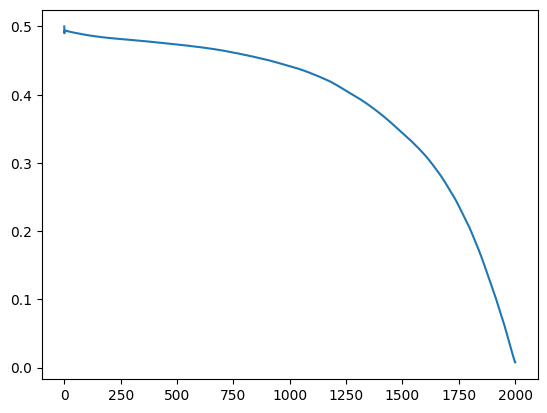

  2.1%   53 of 2500 [----------------------------------------] 22:47:02